In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'
    colab = False

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.v2 as tv2
import torchvision.datasets as tds
import torchvision.utils as tu
import torchvision.ops as tvo
import torchvision

from torchinfo import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
COCO=False
VOC=True

In [3]:
# https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_e2e.html
if COCO:
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img_train = tds.CocoDetection(
        root=dataset_root + '/coco/train2017/',
        annFile=dataset_root + '/coco/annotations/instances_train2017.json',
        transforms=train_tfs_v2
    )

    img_train = tds.wrap_dataset_for_transforms_v2(img_train)

    img_val = tds.CocoDetection(
        root=dataset_root + '/coco/val2017/',
        annFile=dataset_root + '/coco/annotations/instances_val2017.json',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)
elif VOC:
    nn_dim = (640, 640)
    train_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.RandomHorizontalFlip(0.5),
        tv2.RandomResizedCrop(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    val_tfs_v2 = tv2.Compose([
        tv2.ToImage(),
        tv2.Resize(nn_dim, antialias=True),
        tv2.SanitizeBoundingBoxes(),
        tv2.ToDtype(torch.float32, scale=True),
        tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        tv2.ConvertBoundingBoxFormat('XYWH'),
    ])

    img_train = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='train',
        transforms=train_tfs_v2
    )
    img_train = tds.wrap_dataset_for_transforms_v2(img_train)


    img_val = tds.VOCDetection(
        root=dataset_root,
        download=True,
        year='2012',
        image_set='val',
        transforms=val_tfs_v2
    )
    img_val = tds.wrap_dataset_for_transforms_v2(img_val)

Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets
Using downloaded and verified file: ./datasets/VOCtrainval_11-May-2012.tar
Extracting ./datasets/VOCtrainval_11-May-2012.tar to ./datasets


In [4]:
class VocDetectionWrapper():
    def __init__(self, voc, num_slots):
        self.voc = voc
        self.num_classes = 20
        self.num_slots = num_slots
        self.null_class = 0
    
    def __getitem__(self, ix):
        img, boxes = self.voc[ix]

        box = boxes['boxes'].data
        num_boxes, _ = box.shape
        padded_boxes = F.pad(box, (0, 0, 0, self.num_slots - num_boxes))
        
        label = boxes['labels']
        # Null class is always the highest class num
        padded_labels = F.pad(label, (0, self.num_slots - num_boxes), value=self.null_class)
        
        boxes['boxes'].data = padded_boxes / 640
        boxes['labels'] = F.one_hot(padded_labels.to(torch.long), num_classes=self.num_classes + 1)
        
        return img, boxes
    
    def __len__(self):
        return len(self.voc)
    
detr_train = VocDetectionWrapper(img_train, 100)
detr_val = VocDetectionWrapper(img_val, 100)

ValueError: Boxes need to be in (xmin, ymin, xmax, ymax) format. Use torchvision.ops.box_convert to convert them

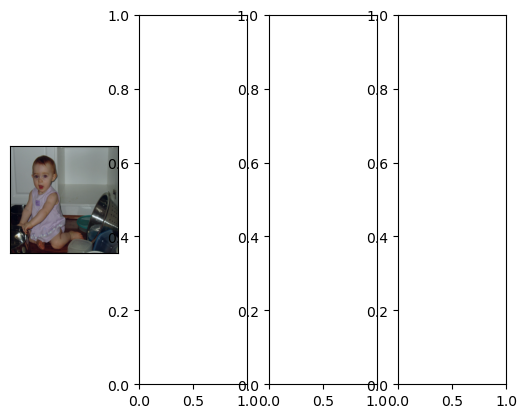

In [5]:
from helpers import plot
ix = 400
samples = []
for x in range(4):
    i, b = detr_train[ix + x]
    samples.append((i, b['boxes']))
    
plot(samples)

ValueError: Boxes need to be in (xmin, ymin, xmax, ymax) format. Use torchvision.ops.box_convert to convert them

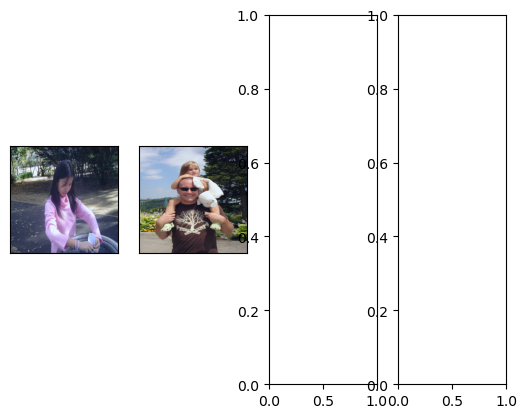

In [6]:
ix = 100
samples = []
for x in range(4):
    i, b = detr_val[ix + x]
    samples.append((i, b['boxes']))
plot(samples)

In [7]:
batchsize = 16

train_loader = tud.DataLoader(detr_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(detr_val, num_workers=cpu_num, batch_size=batchsize, shuffle=True)

In [8]:
class BackBone(nn.Module):
    def __init__(self, out_channels=128):
        super().__init__()
        self.backbone = torchvision.models.shufflenet_v2_x1_0(weights='IMAGENET1K_V1')
        self.conv_out = nn.Conv2d(1024, out_channels, kernel_size=1, padding=0, stride=1)
    
    def forward(self, x):
        # Copy paste from Shufflenet source code with final class head removed.
        x = self.backbone.conv1(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.stage2(x)
        x = self.backbone.stage3(x)
        x = self.backbone.stage4(x)
        x = self.backbone.conv5(x)
        # x = x.mean([2, 3])  # globalpool
        # x = self.fc(x)
        x = self.conv_out(x)
        return x
    
    
class Embeddings(nn.Module):
    def __init__(self, emb_len, patch_num, dropout=0.1):
        super().__init__()
        self.pos_emb = nn.Parameter(
            torch.randn(1, patch_num, emb_len)
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        b, c, ph, pw = x.shape
        x = x.flatten(2)
        x = x.permute(0,2,1)
        x = x + self.pos_emb # I think pos_emb is automatically broadcast in the batch dimension here.
        x = self.dropout(x)
        return x

class Encoder(nn.Module):
    def __init__(self, emb_len, patch_num, layers=4, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        # layer_norm = nn.LayerNorm(emb_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_len,
            nhead=heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True # <-- This took me forever to find, default is to place batch in the second dimension
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
            # norm=layer_norm
        )
    
    def forward(self, x):
        x = self.transformer(x)
        return x

class Decoder(nn.Module):
    def __init__(self, emb_len, query_num, layers=4, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=emb_len,
            nhead=heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True # <-- This took me forever to find, default is to place batch in the second dimension
        )
        self.transformer = nn.TransformerDecoder(
            decoder_layer,
            num_layers=layers,
            # norm=layer_norm
        )
        self.query_embs = nn.Parameter(torch.randn(1, query_num, emb_len))

    def forward(self, x):
        b, q, e = x.shape
        query_embs = self.query_embs.expand(b, -1, -1)
        x = self.transformer(query_embs, x)
        return x
    
# Incoming tensor like 1, 100, 128 for batch, queries, embedding size.
# Want to produce 100 cls+bbox combos with discrete FFNs
class BoxFFN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.relu = nn.ReLU()
        self.sig = nn.Sigmoid()
        self.lin0 = nn.Linear(input_dim, input_dim)
        self.lin1 = nn.Linear(input_dim, input_dim)
        self.lin2 = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        x = self.lin0(x)
        x = self.relu(x)
        x = self.lin1(x)
        x = self.relu(x)
        x = self.lin2(x)
        x = self.sig(x)
        return x

class Detr(nn.Module):
    def __init__(self, num_classes=21, d_model=128):
        super().__init__()
        self.d_model=d_model
        self.backbone = BackBone(d_model)
        self.projection = Embeddings(d_model, 20*20)
        self.encoder = Encoder(d_model, 20*20)
        self.decoder = Decoder(d_model, 100)
        self.bbox = BoxFFN(d_model, 4)
        self.cls = nn.Linear(d_model, num_classes)
        
        for param in self.backbone.parameters():
            param.requires_grad = False

    
    def forward(self, x):
        x = self.backbone(x)
        x = self.projection(x)
        x = self.encoder(x)
        x = self.decoder(x)
        bboxes = self.bbox(x)
        classes = self.cls(x)
        return ({"bboxes": bboxes, "classes": classes})

In [12]:
import scipy.optimize as spo

def xywh_to_xyxy(boxes):
    batch, slot, _ = boxes.shape
    boxes[..., 2] = boxes[..., 0] + boxes[..., 2]
    boxes[..., 3] = boxes[..., 1] + boxes[..., 3]
    return boxes

# Match model outputs to label boxes, then compute classification and bbox losses.
# Both the target and label should be prepadded to 100 slots before this is called
# targets and labels should have a shapes like this for a model with 100 prediction slots
# classification
# - B, 100, class_num
# bbox
# - B, 100, 4, where 4 is in xyxy format.
class MatchingLoss(nn.Module):
    def __init__(self, height, width):
        super().__init__()
        
        self.height = height
        self.width = width
        
        self.class_loss_fn = nn.CrossEntropyLoss()
        self.bbox_loss_fn = nn.MSELoss()
        
        self.cl_loss_scaler = 1.0
        self.bbox_loss_scaler = 1.0
        self.giou_loss_scaler = 1.0

    def forward(self, preds, targets):
        # batchsz, 100, class_num
        assert preds['classes'].shape == targets['classes'].shape
        # batchsz, 100, 4, where 4 is in xyxy format.
        assert preds['bboxes'].shape == targets['bboxes'].shape

        assert preds['bboxes'].shape[0:2] == preds['classes'].shape[0:2]
        
        batch, slots, _ = preds['bboxes'].shape
        
        with torch.no_grad():
            # pred_classes = preds['classes'].reshape(batch * slots, -1)
            # target_classes = targets['classes'].reshape(batch * slots, -1)
            # class_loss = self.class_loss(pred_classes, target_classes)
            class_costs = torch.cdist(
                F.softmax(preds['classes'], dim=2),
                F.softmax(targets['classes'], dim=2),
            p=1.0)

            xyxy_preds = xywh_to_xyxy(preds['bboxes'].clone())
            xyxy_targets = xywh_to_xyxy(targets['bboxes'].clone())
            
            bbox_costs = torch.cdist(xyxy_preds, xyxy_targets, p=1.0)

            agg_loss = self.cl_loss_scaler * class_costs + self.bbox_loss_scaler * bbox_costs

            cost_matrix = agg_loss.reshape(batch, slots, -1)

            out_classes = torch.ones_like(targets['classes'])
            out_bboxes = torch.ones_like(xyxy_targets)
            for b in range(batch):
                preds_idx, targets_idx = spo.linear_sum_assignment(cost_matrix[b, ...].cpu())

                # Rearrange the targets to be in the same indicies as the best matching prediction
                for i, j in zip(preds_idx, targets_idx):
                    out_classes[b, i, :] = targets['classes'][b, j, :]
                    out_bboxes[b, i, :] = targets['bboxes'][b, j, :]


            rearranged_targets = {'classes': out_classes, 'bboxes': out_bboxes}
        
        # At this stage, rearranged_targets holds the targets with the rows swapped
        # to be index aligned per batch with the best prediction box.
        
        # print(preds, "\n\n", rearranged_targets)
        class_loss = self.class_loss_fn(
            preds['classes'],
            rearranged_targets['classes']
        )
        bbox_loss = self.bbox_loss_fn(
            xyxy_preds,
            xyxy_targets
        )
        giou_loss = 1.0 * tvo.generalized_box_iou_loss(
            preds['bboxes'].flatten(0, 1),
            rearranged_targets['bboxes'].flatten(0, 1),
            reduction='mean'
        )
        # print("cl", class_loss, "bb", bbox_loss, "g", giou_loss)
        
        # print(class_loss, bbox_loss, giou_loss)
        agg_loss = self.cl_loss_scaler * class_loss \
            + self.bbox_loss_scaler * bbox_loss \
            + self.giou_loss_scaler * giou_loss
        return agg_loss, class_loss, bbox_loss, giou_loss
        

In [13]:
bb = torch.tensor([
    [0, 0, 1, 1],
    [1, 1, 2, 2],
    [2, 3, 3, 4]
], dtype=torch.float32).unsqueeze(0)
cl = torch.tensor([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1]
], dtype=torch.float32).unsqueeze(0)

rbb = torch.rand_like(bb)
rcl = torch.rand_like(cl)

pbb = torch.tensor([
    [1.01, 0.99, 1.99, 2.1],
    [-0.5, 0.2, 1.2, 1.3],
    [2.2, 2.8, 3.1, 4.2]
], dtype=torch.float32).unsqueeze(0)
pcl = torch.tensor([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
], dtype=torch.float32).unsqueeze(0)


v = {'classes': cl.expand(2, -1, -1), 'bboxes': bb.expand(2, -1, -1)}
pv = {'classes': pcl.expand(2, -1, -1), 'bboxes': pbb.expand(2, -1, -1)}
rv = {'classes': rcl.expand(2, -1, -1), 'bboxes': rbb.expand(2, -1, -1)}

m = MatchingLoss(640, 640)
print(m(v, v))

(tensor(0.5514), tensor(0.5514), tensor(0.), tensor(1.1921e-07))


In [14]:
model = Detr(21, 256)
print(summary(model, (7,3,640,640)))
if False:
    import timeit
    with torch.no_grad():
        m = model.eval().cpu()
        print(m.d_model)
        testdata = torch.randn(1,3,640,640).cpu()
        times =timeit.timeit(stmt='m(testdata)',globals=globals(), number=100)
    times/100

Layer (type:depth-idx)                             Output Shape              Param #
Detr                                               [7, 100, 21]              --
├─BackBone: 1-1                                    [7, 256, 20, 20]          --
│    └─ShuffleNetV2: 2-1                           --                        1,025,000
│    │    └─Sequential: 3-1                        [7, 24, 320, 320]         (696)
│    │    └─MaxPool2d: 3-2                         [7, 24, 160, 160]         --
│    │    └─Sequential: 3-3                        [7, 116, 80, 80]          (30,192)
│    │    └─Sequential: 3-4                        [7, 232, 40, 40]          (244,180)
│    │    └─Sequential: 3-5                        [7, 464, 20, 20]          (501,352)
│    │    └─Sequential: 3-6                        [7, 1024, 20, 20]         (477,184)
│    └─Conv2d: 2-2                                 [7, 256, 20, 20]          (262,400)
├─Embeddings: 1-2                                  [7, 400, 256]       

In [17]:
import numpy as np

epochs = 100
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
criterion = MatchingLoss(640, 640)

loss_plot = []
for epoch in range(epochs):
    model.train()
    losses = []
    for i, (images, target) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        images = images.float().to(device)
        bboxes = target['boxes'].to(device)
        classes = target['labels'].to(device)

        outs = model(images)
        
        loss, cl, bb, giou = criterion(outs, {'classes': classes.float(), 'bboxes': bboxes.float()})
        
        losses.append([
            loss.detach().item(),
            cl.detach().item(),
            bb.detach().item(),
            giou.detach().item()
        ])
        loss.backward()
        optimizer.step()
    # print(np.array(losses).shape)
    print(np.array(losses).transpose().mean(axis=1))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [00:22<00:00, 15.76it/s]


[27.2199043  21.90289742  0.4834727   4.8335342 ]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [00:22<00:00, 16.00it/s]


[25.33382345 21.89672488  0.49596606  2.94113244]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [00:22<00:00, 15.98it/s]


...

[2.25242419e+01 2.16221758e+01 8.69578681e-03 8.93370260e-01]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 358/358 [00:22<00:00, 15.82it/s]


[2.25095382e+01 2.16203802e+01 8.66630424e-03 8.80491730e-01]


 19%|█████████████████████████                                                                                                         | 69/358 [00:05<00:21, 13.27it/s]


KeyboardInterrupt: 

In [22]:
model(img_train[1][0].cuda().float().unsqueeze(0))

{'bboxes': tensor([[[6.0789e-15, 1.1927e-15, 1.2681e-08, 3.0580e-08],
          [3.7862e-15, 7.2013e-16, 8.3620e-09, 2.6538e-08],
          [4.4891e-15, 8.1545e-16, 8.0792e-09, 2.5477e-08],
          [7.6597e-17, 1.0996e-17, 2.9279e-09, 9.1144e-09],
          [2.2528e-14, 3.6418e-15, 1.8771e-08, 6.0392e-08],
          [1.2359e-14, 2.1424e-15, 1.2066e-08, 3.7400e-08],
          [4.4906e-15, 8.4815e-16, 8.9958e-09, 3.4824e-08],
          [1.6193e-14, 3.1314e-15, 1.7374e-08, 5.5589e-08],
          [3.7221e-15, 6.3457e-16, 6.1453e-09, 1.4031e-08],
          [1.0966e-14, 2.2748e-15, 8.9183e-08, 1.1353e-07],
          [1.6361e-14, 2.9674e-15, 1.7823e-08, 6.0764e-08],
          [2.5506e-16, 3.8460e-17, 3.6526e-09, 1.4329e-08],
          [2.0480e-14, 3.6784e-15, 1.7096e-08, 5.2334e-08],
          [1.8790e-13, 3.5957e-14, 5.3471e-08, 1.5213e-07],
          [5.3218e-14, 1.1360e-14, 3.1816e-08, 8.5045e-08],
          [4.0814e-14, 9.5744e-15, 2.2233e-07, 2.2178e-07],
          [1.8536e-15, 2.8296e